# Dynamic Pricing TS Notebook

This notebook accompanies the  [Thompson Sampling (TS) Dynamic Pricing Tutorial paper](./dyanamic_pricing_ts.md). 

The TS algorithm is modeled numerically with the PyMC Python library for Baysian statistical modeling and probabilistic machine learning. The specific objective of this notebook is to model the posterior probability $P(\theta|Demand),\,  \theta = (a,v, sigma_{log})$. The $\theta$ parameters $(a,v,sigma_{log})$ are parameters coresponding to the constant elasticity of demand, $D(p) = a p ^{-v}$.

After the notebook setup (Imports), the demand and corresponding parameters are chosen, and we visulize the classic demand, price, and profit relationship. Next, we choose the hyperparametes of our statistical model, followed by visualizing the demand likelihood and prior-probabilities of our statistical model. We then setup the PyMc TS Dynamic pricing model, in the form of a Python class. follwed by a TS Dynamic pricing simulation, and then save the results. 

Contents
* Imports and Notebooks Setup
* Demand and TS Parameters
* Economics - Price, Demand, Revenue, Profit
* Demand LogNormal PDF
* Priors - a, v, CV
* Graph - Likelihood and Priors
* PyMC TS Dynamcic Pricing  Model
* TS Dynamic Pricing Simulation
* Save Rusults

The notebook [ts_simulation_results_analysis.ipynb](ts_simulation_results_analysis.ipynb) provides analysis of TS simulation in this notebook.


# Imports

In [1]:
# Good to know the Python version
!python --version

Python 3.12.7


In [1]:
# General Imports
import numpy as np
import pandas as pd
import beautifulplots as bp
import matplotlib.pyplot as plt

import pymc as pm

# Set Seed
np.random.seed(42) # keeps stats numbers repeatable ... convenientfor initial development

# Demand and TS Parameters

In [98]:
example_case = "case2"

variable_cost = 1.2
fixed_cost = 6
v_true = 1.8
a_true = 4000

# low variability
if example_case == "case1": # hard example 
    CV_true = .05
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6 # w sigma_log .04 can be further away from optimal price

    
elif example_case == "case2": # medium difficutlty
    CV_true = .20
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6  # w sigma_log .15 need to be closer to target

elif example_case == "case3" : # hard
    CV_true = .30
    sigma_log_true = np.sqrt(np.log1p(CV_true**2)) # sqrt(1 + CV^2)
    p1 = 3.6

else:   # default to None
    v_true = None
    a_true = None
    sigma_log_true = None
    variable_cost = None
    fixed_cost = None
    p1 = None
m_log = a_true + p1 ** (-v_true) # logD before additive noise
d1m =  a_true * p1 ** (-v_true) * np.exp(sigma_log_true**2 / 2) # E[D] at p1
    
print(f'example: {example_case}')
print(f'v_true = {v_true}')
print(f'a_true = {a_true}')
print(f'CV_true = {CV_true}')
print(f'sigma_log_true = {round(sigma_log_true,2)}')
print(f'variable_cost = {variable_cost}')
print(f'fixed_cost = {fixed_cost}')
print(f"p1 (initial price point) = {p1}")
print(f"d1m = (E[D] at p1) = {round(d1m,2)}")


example: case2
v_true = 1.8
a_true = 4000
CV_true = 0.2
sigma_log_true = 0.2
variable_cost = 1.2
fixed_cost = 6
p1 (initial price point) = 3.6
d1m = (E[D] at p1) = 406.66


Mean demand at price p  
$E[D] = \mu_{linear}= e^{\mu_{log} + \frac{1}{2} \sigma_{log}^2} = a p ^{-v}e^{\frac{\sigma_{log}^2}{2}}$ 

d1m E[D|p1] above is derived with this formula

#### Derived Parameters

In [99]:
# derived parameters

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
    
print(f'p_opt = {round(p_opt,2)}, ... optimal price given true params')
print(f'D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')



p_opt = 2.7, ... optimal price given true params
D_opt = 669.28, ... optimal demand given true params
Profit_opt = 997.91, ... optimal profit given true params
D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6


#### Hyperparameters

In [100]:
# Prior a hyperparameters
  #   - important, can get large and blow things out
  #   - careful with  CV = sigma_a / mu_a
  #   - CV = 0.2 tight good (sigma_a = 600/3000), 
  #   - CV = 0.4 = reasonable, well behaved posterior
m_a, sigma_a = 3500, 1200 

# Prior v hyperparameters 
   #  - ecommerce demand [1.4 , 1.8]
   #  -  sigma_v .3 to .4 good
   #  - sigma_v  0.5 noisy demand ... borderline large
   #  - values near 1 can cause large price swings
   #  - truncated notrmal lower_v hyper ... prevent gettng too close to 1
   # parameters ... m_vtn, signma_v
   
m_v, sigma_v = 1.5, 0.4    #  hyperparameters for prior v
lower_v = 1.1
upper_v = np.inf

if example_case == "case1":
    CV = .06
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case2":
    CV = .15
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
elif example_case == "case3":
    CV = .25
    sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
else:
    CV = None
    sigma_log = None

print(f'hyperparameters = m_a = {m_a}, sigma_a = {sigma_a}')
print(f'hyperparameters = m_v = {m_v}, sigma_v = {sigma_v}')
print(f'hyperparameters = CV = {CV}')
print(f'      sigma_log = {sigma_log}')

# min and max initial price range 
# - used for initial optimum price estimate
price_min = 2 
price_max = 6
print()
print(f'price_min = {price_min}')
print(f'price_max = {price_max}')

hyperparameters = m_a = 3500, sigma_a = 1200
hyperparameters = m_v = 1.5, sigma_v = 0.4
hyperparameters = CV = 0.15
      sigma_log = 0.149166380041951

price_min = 2
price_max = 6


About CV
For our Bandit TS Dynamic Pricing Model

Practical heuristics
* There is no paper that states specific CV thresholds
* Observations, experience results in heuristics for this model  like 0.05 = easy, 0.15 = moderate, 0.30 = hard for Thompson Sampling dynamic pricing.

Why? High observation noise slows posterior concentration

Russo et al. (2018), A Tutorial on Thompson Sampling
→ Regret bounds worsen as noise variance increases.

Regret scales with noise variance

Agrawal & Goyal (2012, 2013)
→ Regret bounds contain σ² (noise variance) terms.

Dynamic pricing with demand noise

Ferreira et al. (2018), Management Science
→ Performance deteriorates as demand variance increases.

# Economics: Price, Demand, Revenue, Profit

In [101]:
# Revenue and Profit ... MR and MC .... y2 legend location
p = np.linspace(1, 10, 100)
D = a_true * p **(-v_true)  # Demand
R = p * D  # Revenue
TC = fixed_cost + variable_cost * D   # Total Cost
ACPU =   ( fixed_cost / a_true ) * (p ** v_true) + variable_cost  # = TC / D ... average cost per Unit
P = R - TC # Profit
RPU = R / D # Revenue per Unit
MR = p * (1 - 1/ v_true) #
MC = variable_cost # Marginal Cost
ACPU_p_opt = (fixed_cost + variable_cost * D_opt ) / D_opt # NOTE: ACPU is not exactly = MC 
TC_p_opt = fixed_cost + variable_cost * D_opt
D_p1 = a_true * p1 **(-v_true)
TC_p1 = fixed_cost + variable_cost * D_p1

Profit_opt = D_opt * p_opt - TC_p_opt

print(f'p1 = {p1}, ... Initial Price Point')
print(f'D_p1 = {round(D_p1,2)}, ... Mean Demand at Initial Price Point')
print(f'TC_p1 = {TC_p1}, ...  Total Cost at initial price point')
print(f'p_opt = {round(p_opt,2)}, ... Optimal Price Point')
print(f'D_opt = {round(D_opt,2)}, ... Demand at optmal price point')
print(f'TC_p_opt = {TC_p_opt}, ...  Total Cost at optmal price point')
print(f'ACPU_p_opt = {ACPU_p_opt}, ... Avg Cost per Unit at optmal price point')
print(f'Profit_opt = {Profit_opt}, ... Profit at optmal price point')

print()
print('df_demand_profit')
df_demand_profit = pd.DataFrame({'price': p, 'demand': D, 'revenue':R, 'costs': TC, 'profit': P, "acpu":ACPU ,"mr":MR, "mc":MC }) 

df_demand_profit[df_demand_profit['price'] > 1].head(10)

p1 = 3.6, ... Initial Price Point
D_p1 = 398.76, ... Mean Demand at Initial Price Point
TC_p1 = 484.5162999835678, ...  Total Cost at initial price point
p_opt = 2.7, ... Optimal Price Point
D_opt = 669.28, ... Demand at optmal price point
TC_p_opt = 809.131133805389, ...  Total Cost at optmal price point
ACPU_p_opt = 1.208964912075921, ... Avg Cost per Unit at optmal price point
Profit_opt = 997.9139172567361, ... Profit at optmal price point

df_demand_profit


,price,demand,revenue,costs,profit,acpu,mr,mc
1,1.090909,3420.113996,3731.033450,4110.136795,-379.103345,1.201754,0.484848,1.2
2,1.181818,2961.207158,3499.608459,3559.448589,-59.840130,1.202026,0.525253,1.2
3,1.272727,2591.411373,3298.159929,3115.693647,182.466282,1.202315,0.565657,1.2
4,1.363636,2288.772140,3121.052918,2752.526567,368.526350,1.202621,0.606061,1.2
5,1.454545,2037.749784,2963.999686,2451.299741,512.699945,1.202944,0.646465,1.2
6,1.545455,1827.085059,2823.676909,2198.502071,625.174838,1.203284,0.686869,1.2
7,1.636364,1648.452037,2697.466969,1984.142444,713.324525,1.203640,0.727273,1.2
8,1.727273,1495.582390,2583.278674,1800.698868,782.579806,1.204012,0.767677,1.2
9,1.818182,1363.681135,2479.420245,1642.417361,837.002883,1.204400,0.808081,1.2
10,1.909091,1249.027769,2384.507560,1504.833323,879.674237,1.204804,0.848485,1.2


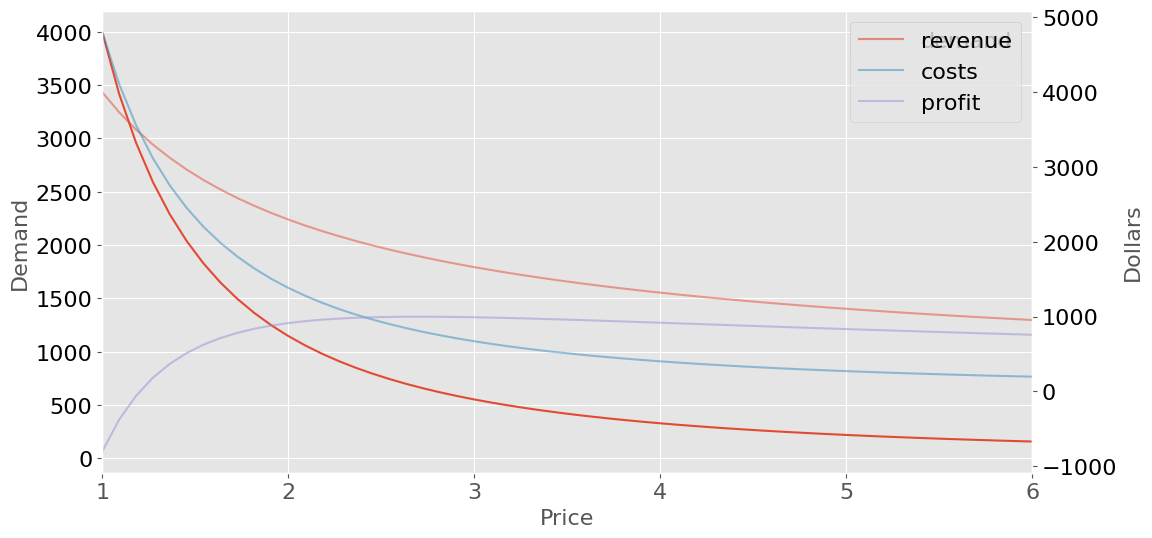

In [102]:

# Plot Demand, Revenue, Costs, Profit vs Price
bp.lineplot(df_demand_profit, 
    x="price",
    y2 = ["revenue", "costs" ,"profit"],
    y = "demand",
    y_axis_label='Demand',
    y_axis_format=".0f",
    y2_axis_label='Dollars',
    y2_axis_format=".0f",
    x_axis_label='Price',
    figsize=(12,6),
    x_lims=(1, 6)
    )

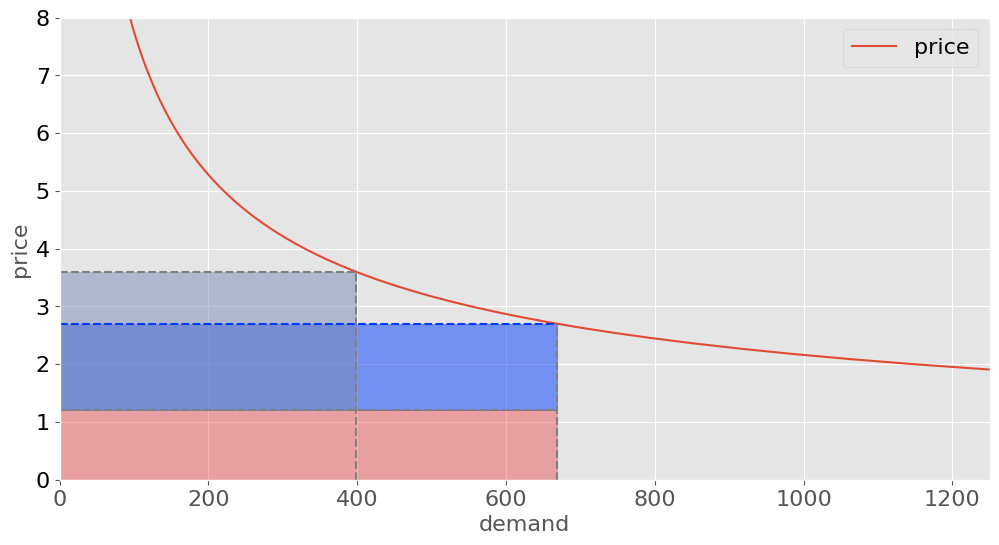

Fig 2: Price, MR, MC vs Demand 


In [103]:
# Print 
fig, ax = plt.subplots(1,1, figsize=(12,6))

# Price Demand
bp.lineplot(df_demand_profit, x='demand', y="price",  y_axis_format=".0f",  x_axis_label='demand', y_axis_label="price",x_lims=(0,1250 ), y_lims = (0,8),    figsize=(12,6), ax=ax)

# Optimal Price, Demand Lines, Total Cost
ax.hlines(y=p_opt, xmin=0, xmax=D_opt,  linestyles='dashed', color='#013BFF')
ax.hlines(y=TC_p_opt/D_opt, xmin=0, xmax=D_opt,  linestyles='dashed', color='gray')
ax.vlines(x=D_opt, ymin=0, ymax=p_opt,  linestyles='dashed', color='gray')
# - Optimal Profit Area
x = np.linspace(0, D_opt, 200)
y_lower = np.full_like(x,TC_p_opt/D_opt)          # curve 1: y = 0
y_upper = np.full_like(x, p_opt)    # curve 2: y = p_opt
ax.fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#013BFF", alpha=0.5) # revenue area

# Cost area at optimal price
y_lower = np.full_like(x,0)        # curve 1: y = 0
y_upper = np.full_like(x, TC_p_opt/D_opt)  # curve 2: y = TC per unit at p_opt
ax.fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#F10007", alpha=0.3) # cost area

# Starting Pice and Demand Points
ax.hlines(y=p1, xmin=0, xmax=D_p1, linestyles='dashed', color='gray')
ax.vlines(x=D_p1, ymin=0, ymax=p1,  linestyles='dashed', color='gray')
# p1 profit area
x = np.linspace(0, D_p1, 200)
y_lower = np.full_like(x,TC_p1/D_p1)  # curve 1: y = TC per unit at p1
y_upper = np.full_like(x, p1)    # curve 2: y = p_opt
ax.fill_between( x=x,  y1=y_lower, y2=y_upper,   color="#7B8CB4", alpha=0.5) # revenue area

#ax.annotate("____",xy=(2.8,940))
#ax.annotate("(\\$2.25,929)", xy= (2.5,1000),   fontsize=14  )

plt.show()

print(f"""Fig 2: Price, MR, MC vs Demand """)

# Demand Log Normal PDF

In [104]:
from utils_probability import demand_lognormal_pdf

d = np.linspace(100,2000,500)

# log D is Normal, then D is logNormal
# dispersion of demand is controlled by sigma_log, which is the standard deviation of log D
# CV is converted to sigma_log in the function
# sigma_log = np.sqrt(np.log1p(CV**2)) # sqrt(1 + CV^2)
# mu = np.log(a) - v * np.log(p_opt) ... this is the log of the mean demand at p_opt
density_d = demand_lognormal_pdf(d, a_true, v_true, p_opt, CV_true)

df_prob_demand = pd.DataFrame({"demand":d, "prob_demand_p2.7": density_d})

max_index = df_prob_demand["prob_demand_p2.7"].idxmax() # index of max probability

print(f'max_index = {max_index}')

df_prob_demand.loc[max_index-3:max_index+3]

max_index = 143


,demand,prob_demand_p2.7
140,633.066132,0.003059
141,636.873747,0.003065
142,640.681363,0.003069
143,644.488978,0.003069
144,648.296593,0.003067
145,652.104208,0.003063
146,655.911824,0.003055


In [105]:
# D_mode corresponds to the center of the statistical demand function
D_mode = D_opt*(np.e**(- 1.5*sigma_log_true**2)) 

# alternative, equivalent calculation
mu_log = np.log(a_true) - v_true * np.log(p_opt)
D_mode = np.exp(mu_log - sigma_log**2)

print(f'D_mode = {round(D_mode,2)}')

D_mode = 654.55


# Priors - a , v, CV 

Prior a
* prioir is precisely modeled in log-space, log a. 
* For easier interpretability we caclulate and graph a

In [106]:
# Shaping Parameter Prior a
# Lognormal

from utils_probability import lognormal_pdf_from_linear

print("hyperparameters for prior a (lognormal)")
print(f'm_a = {m_a}')
print(f'sigma_a = {sigma_a}')

# practical approximation (commonly used):
sigma_log_a = np.sqrt(np.log(1 + (sigma_a / m_a)**2))
sigma_log_a.item()

a = np.linspace(1,10000, 100)
sigma_tn = 100

cv_a = sigma_a / m_a
print(f'cv_a = {cv_a}')

#prob_a = lognormal_pdf(x=a, m=np.log(m_a),sigma=sigma_log_a)
prob_a = lognormal_pdf_from_linear(x=a, mean=m_a, cv=cv_a)

# find mid_point values ... to get sense of numbers
mid_a=int(np.floor(len(a)/2).item())
mid_prob = int(prob_a[mid_a].item())
df_prob_a = pd.DataFrame({'a': a, 'ln_a': np.log(a), 'prob_a': prob_a})

print(f'prob_a_mid({mid_a}) = {prob_a[mid_a]}')
print(df_prob_a["prob_a"].sum())


hyperparameters for prior a (lognormal)
m_a = 3500
sigma_a = 1200
cv_a = 0.34285714285714286
prob_a_mid(50) = 0.00010617077695248425
0.009896706176866629


Prior v
- truncated Normal
- the translation of normal to truncated normal shifts the respective mean

In [107]:
# Prior v 
#  v = demand elasticity
#  truncated_normal
from utils_probability import truncated_normal_pdf, truncated_normal_mean

# - since v = 1 is a discontinuity 
# - therefore, lower truncated normal for prior v
# - lower limit = 1.1 
# - mean of 1.5 here is an effecitve mean of 1.6
m_vtn = truncated_normal_mean(mu=m_v, sigma=sigma_v, a=lower_v)
vtn_true = truncated_normal_mean(mu=v_true, sigma=sigma_v, a=lower_v)
print(f'm_v = {m_v}')
print(f'm_vtn = {round(m_vtn,2)}')
print()
print(f'v_true = {round(v_true,2)}')
print(f'vtn_true = {round(vtn_true,2)}')

# example inputs
v = np.linspace(lower_v, 4, 100)

# prob_v
prob_v = truncated_normal_pdf(
                x=v,    
                m=m_v,  
                sigma=sigma_v,  
                lower_limit=lower_v, 
                upper_limit=upper_v
          )

# Elasticiay Parameter Prior
df_prob_v = pd.DataFrame({'v': v, 'prob_v': prob_v})



m_v = 1.5
m_vtn = 1.62

v_true = 1.8
vtn_true = 1.84


Prior sigma_log
* CV is the coeficient of variaion of demand, D
* sigm_log is the log D, standard deviation of log D, sigma_log = $\sqrt{1 + CV^2}$ 

In [108]:
# Prior sigma_log
# sigma_log = sqrt(1+ CV^2)
# half-normal
from utils_probability import  half_normal_pdf
# PyMC half normal ... for paramter sigma_log
#    if want a, "mean" (offse) then need to add offset constant

sigma_log = np.sqrt(np.log1p(CV**2)) # sigma_log derived from CV
mu_hn = sigma_log * np.sqrt(2/np.pi) # mu_hn this is not an input to the half normal. It is convenient for graphing later.


_sigma_log = np.linspace(1e-6, .5, 100)
prob_sigma_log = half_normal_pdf(_sigma_log, sigma=sigma_log)

# convienent to get some values for the densities
mid_sigma_log =int(np.floor(len(_sigma_log)/2).item())

df_prob_sigma_log = pd.DataFrame({'sigma_log': _sigma_log, 'prob_sigma_log': prob_sigma_log})

p_sigma_log_density = np.interp(sigma_log, _sigma_log, prob_sigma_log)

print(f'sigma_log = {sigma_log}')
print(f'prob_density(sigma_log) = {p_sigma_log_density}')


# trapezpoid takes the average of the two endpoints of each interval, 
# multiplies by the width of the interval, and sums these products to get 
# an approximation of the area under the curve.
area_sigma_log=np.trapezoid(prob_sigma_log, _sigma_log)
print(f'area_sigma_log = {area_sigma_log}')

# density starts large and gets small fast
df_prob_sigma_log.head(5)


sigma_log = 0.149166380041951
prob_density(sigma_log) = 3.2443057017026904
area_sigma_log = 0.9991913125537023


,sigma_log,prob_sigma_log
0,0.000001,5.348957
1,0.005051,5.345891
2,0.010102,5.336705
3,0.015152,5.321431
4,0.020203,5.300121


# Graph Likelihood and Priors


graphs are tuned to case 1 

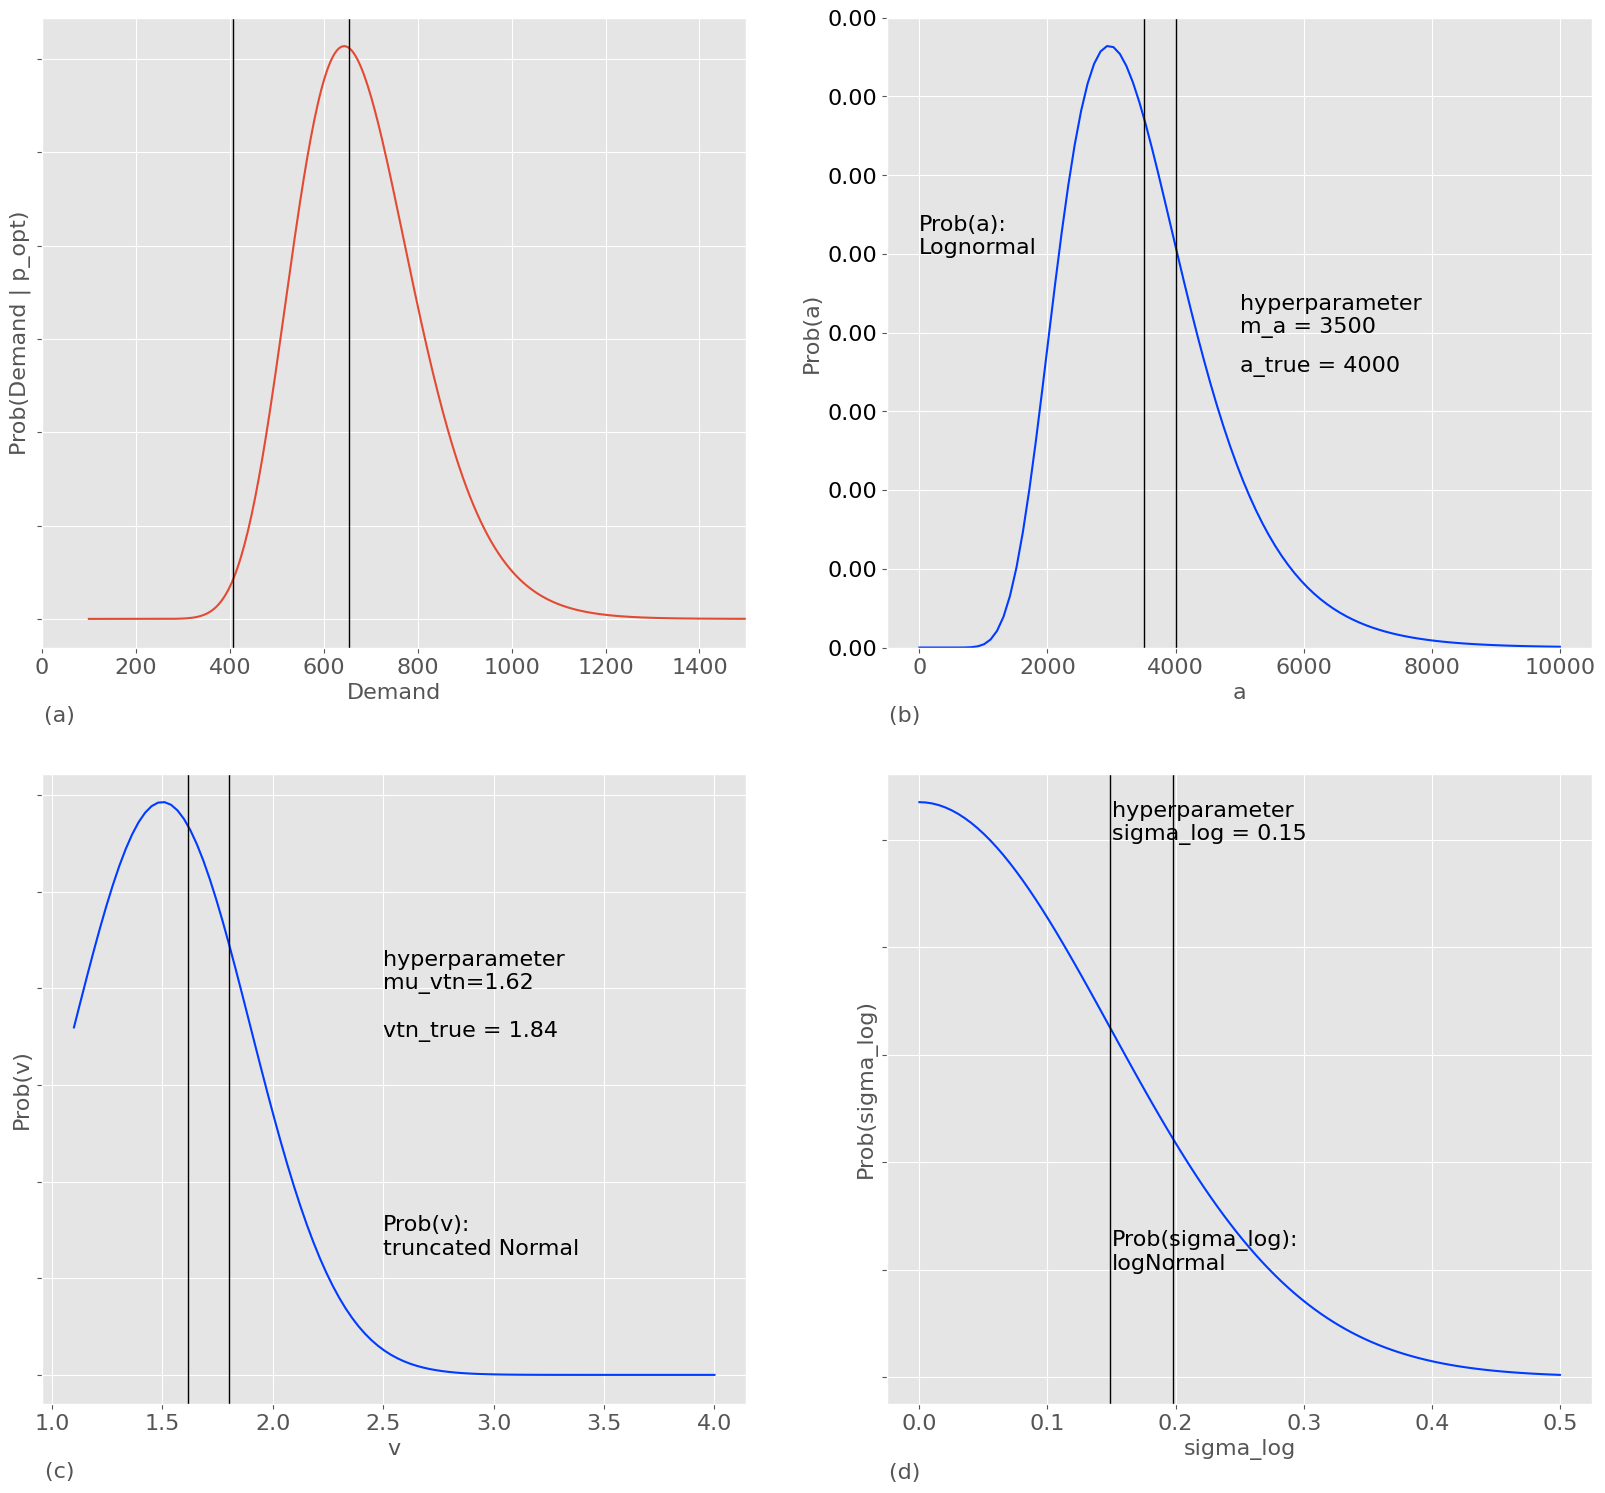

Fig 2: Prior Distributions and Likelihood


In [109]:
## Graph Likelihood and Priors
# 2 x2 subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 18))

####################################################
### Probability Demand Likelihood, LogNormal subplot (a)  ####
label_and_graph_no_str = """Demand
(a)                                                                                              """
bp.lineplot(df_prob_demand, 
    x='demand', 
    y=['prob_demand_p2.7'],  
    x_axis_label=label_and_graph_no_str, 
    legend = False,
    annotate = [  
        (f"E[D|p1]=\n {round(d1m,0)}",(100,.005)),
        ("P(D | theta_true):\nLogNormal\nmultiplcative noise",(800, 0.01)),
        (f"D_opt = {round(D_opt)}",(800, 0.006)),
        (f"D_mode={round(D_mode,2)}\np_opt = ${round(p_opt,2)}",(800, 0.004)),

           ],
    v_line = [d1m,D_mode],
    x_lims = (0, 1500),
    y_axis_label='Prob(Demand | p_opt)', 
    figsize=(18,6), 
    ax = axs[0,0] )


axs[0,0].tick_params(axis='y', labelleft=False)

#########################################
#####  Prior a, subplot (b). #############
#  lognormal
label_and_graph_no_str = """a
(b)                                                                                              """
bp.lineplot(df_prob_a, x='a', y='prob_a', 
            x_axis_label=label_and_graph_no_str, 
v_line = [m_a, a_true],
legend = False,
y_axis_label='Prob(a)', 
annotate = [(f"hyperparameter\nm_a = {m_a}" ,
             (5000, .0002)),
            (f"a_true = {a_true}",(5000, .000175)),
            ("Prob(a):\nLognormal",(0,.00025))
           ],
y_lims = (0, .0004),
ax = axs[0,1], color='#013BFF'
)

#####################################
##### Prior v, subplot (c) ##########
label_and_graph_no_str = """v
(c)                                                                                              """
bp.lineplot(df_prob_v, x='v', y='prob_v',  x_axis_label=label_and_graph_no_str,
legend = False,
annotate = [("Prob(v):\ntruncated Normal" ,(2.5, 0.25)),
            (f"hyperparameter\nmu_vtn={round(m_vtn,2)}", (2.5,.8)),
            (f"vtn_true = {round(vtn_true,2)}" ,(2.5, .7)),
            ],
y_axis_label='Prob(v)', ax = axs[1,0], 
v_line = [m_vtn,v_true],
color='#013BFF')
axs[1,0].tick_params(axis='y', labelleft=False)


#######################################################
######### Prior sigma_log, subplot (sigma_log) ########
label_and_graph_no_str = """sigma_log
(d)                                                                                              """
bp.lineplot(df_prob_sigma_log, x='sigma_log', y='prob_sigma_log', x_axis_label=label_and_graph_no_str,
legend = False,
y_axis_label='Prob(sigma_log)', 
v_line = [sigma_log_true, sigma_log],
ax = axs[1,1], 
annotate = [   ( ("Prob(sigma_log):\nlogNormal"), (.15, 1)),
               (f"sigma_log_true = {round(sigma_log_true,2)}", (.15,7)),
               (f"hyperparameter\nsigma_log = {round(sigma_log,2)}", (.15,5))
             ],
color='#013BFF')
axs[1,1].tick_params(axis='y', labelleft=False)

plt.show()

print(f"""Fig 2: Prior Distributions and Likelihood""")


# TS Model

In [110]:
from dataclasses import dataclass, field
import numpy as np
import pymc as pm
import random
import arviz as az

import contextlib
from pathlib import Path
import logging


In [111]:

def demand_sample(p: float, a:float, v:float, sigma_log:float):
    """Demand with multiplicative noise.

    Args:
        p (float): _description_
        a (float): _description_
        v (float): _description_
        sigma_log (float): _description_

    Returns:
        float: linear demand sample
    """

    mu_log = np.log(a) - v * np.log(p)
    return np.exp(mu_log + np.random.normal(0, sigma_log))

In [112]:
# TS Dynamic Pricing Model Class

@dataclass
class PymcTsModel:
    m_a: float
    sigma_a: float
    m_v: float
    sigma_v: float
    lower_v: float
    CV_d: float
    p0: float
    y0: float
    price_min: float
    price_max: float
    F: float
    c: float
    
    log_file: str = "tm_model_log.txt"
    verbose: bool = True

    random_seed: int = 42

    model: pm.Model = field(init=False)
    trace: object = field(init=False, default=None)

    # Optional: keep handles to pm.Data containers
    p_data: pm.Data = field(init=False)
    #y_data: pm.Data = field(init=False)
    y_log_data: pm.Data = field(init=False)

    def __post_init__(self):
        
        # quiet PyMC logging!!!!
        if not self.verbose:
            logging.getLogger("pymc").setLevel(logging.ERROR)
            logging.getLogger("pytensor").setLevel(logging.ERROR)
        
        
        # histories live outside the PyMC model context
        self.traces = []
        self.price_history = []
        self.demand_history = []

        # build model + take initial posterior
        self.init_ts_pricing_model()

        # store initial trace + initial observation
        self.traces.append(self.trace)
        self.price_history.append(self.p0)
        self.demand_history.append(self.y0)
        
        
    @contextlib.contextmanager
    def _redirect_io(self):
        if self.verbose:
            yield
            return

        Path(self.log_file).parent.mkdir(parents=True, exist_ok=True)
        with open(self.log_file, "a", buffering=1) as f, \
            contextlib.redirect_stdout(f),  contextlib.redirect_stderr(f):
            yield

    def init_ts_pricing_model(
        self,
        draws: int = 1000,
        tune: int = 2000,
        chains: int = 2,
        target_accept: float = 0.99,
    ):
        
        """ 
        
        Initializes the PyMC Thompson Sampling pricing model and draws samples from the initial posterior distribution.
        
        PyMC is building the posterior probability 
        
        P(theta|D) = Likelihood * Prior(a) * Prior(v) * Prior(sigma_log)
        
        in log-probability space. Therefore, the multiplications are not
        visible, but under the hood PyMC is adding the log probabilities.
        
        * pm.Normal(loga ...) adds log(Prior(a)) to the joint density
        * pm.TruncatedNormal(v ...) adds log(Prior(v)) to the space
        * pm.HalfNormal(sigma_log ...) adds log( Prior(sigma_log)) to the space
        * pm.Normal(logD_obs ...) adds sum(log(Pdi | theta)) to the space
        
        PyMc then samples from
        
        * exp(  log(Prior(a)) +  log(Prior(v)) +  log( Prior(sigma_log)) + sum(log(Pdi | theta))  )
        
        * which is the posterior of interest
          
        Args:
            draws (int): Number of posterior samples per chain.
            tune (int): Number of tuning (warm-up) iterations per chain.
            chains (int): Number of MCMC chains to run.
            target_accept (float): Target acceptance probability for NUTS.

        Returns:
            arviz.InferenceData: Posterior samples for parameters (a, v, sigma_log).
        """
        with pm.Model() as model:
            # ---- Prior for a (LogNormal via loga ~ Normal) ----
            cv2 = (self.sigma_a / self.m_a) ** 2
            sigma_loga = np.sqrt(np.log1p(cv2))  # np.log "1p" 1 plus for numeric stability
            mu_loga = np.log(self.m_a) - 0.5 * sigma_loga**2 

            loga = pm.Normal("loga", mu=mu_loga, sigma=sigma_loga)
            a = pm.Deterministic("a", pm.math.exp(loga))

            # ---- Prior for v (truncated normal) ----
            v = pm.TruncatedNormal(
                "v",
                mu=self.m_v,
                sigma=self.sigma_v,
                lower=self.lower_v,
            )

            # ---- Prior for sigma_log (log-space noise, learned) ----
            #   mean halfNormal is sigma * sqrt(2/pi) so we do not provide a   the mean as input. In this case sigma = sigma_log
            #   Convert linear-scale CV_d to log-scale sigma_log 
            #   (LogNormal relationship)
            sigma_log_scale = np.sqrt(np.log1p(self.CV_d**2)) # self.CV_d is the hyperparameter
        
            # One practical note: if CV_d could be large/noisy from few samples, you may want a slightly “fatter” prior by multiplying sigma_log_scale by, say, 1.5–2.0 (optional), but the math conversion above is the correct baseline.
            
            sigma_log = pm.HalfNormal(
                "sigma_log",
                sigma=sigma_log_scale # hyperparameter in log-scale
            )
            
            cv = pm.Deterministic("cv", pm.math.sqrt(pm.math.exp(sigma_log**2 - 1))) # convert back to linear CV for interpretability ... notice exp "m1" minus 1

            # ---- Mutable data ----
            self.p_data = pm.Data("p_data", np.array([self.p0], dtype=np.float64))
            self.y_data = pm.Data("y_data", np.array([self.y0], dtype=np.float64))

            # ---- Log-space likelihood (multiplicative noise) ----
            #  mean of the log demand
            mu_log = loga - v * pm.math.log(self.p_data) # likelihood mean

            # store log(y) directly as pm.Data (not pm.math.log(y_data))
            self.y_log_data = pm.Data("y_log_data", np.array([np.log(self.y0)], dtype=np.float64))


            pm.Normal(
                "logD_obs",
                mu=mu_log,
                sigma=sigma_log,
                observed=self.y_log_data,
            )

            self.model = model

            with self._redirect_io():   # re-direct io to quiet PyMC!!! too chaty and Ipython Widgets
                self.trace = pm.sample(
                    draws=draws,
                    tune=tune,
                    chains=chains,
                    target_accept=target_accept,
                    random_seed=self.random_seed,
                    progressbar=self.verbose,
                )

        return self.trace
            
    def price_local_random(self, max_price_change):
        """ Random price between min and max change

        Args:
            max_price_change (float): % (between 0 and 1) price change

        Returns:
            float: random price, 2 decimal places
        """
        
        price_min = self.price_history[-1] * (1 - max_price_change)
        price_max = self.price_history[-1] * (1 + max_price_change)

        price = random.uniform(price_min, price_max)
        price = float(np.clip(price, self.price_min, self.price_max))
        price = round(price, 2)

        return price
            
                 
    def price_local_max_profit_sample(self,max_price_change , Npgrid=40, K=1):
        """
        Price that maximizes local profit given a price change constraint and K parameter sample (defaults to K = 1).
        - parameters a and v are drawn from the posterior trace (K samples)
        - optimization is inside the allowed price change region ("trust region") only 
        - price that maximizes the profit given the sample parameters a, v (i.e., v is a new demand curve)

        Args:
            max_price_change (float)): should be a percent (<= 1)
            Npgrid (int, optional): Number of price grid points. Defaults to 40


        Returns:
            float: price that otimizes the profit given parameter sample(s)
        """

        price_min = self.price_history[-1] * (1 - max_price_change)
        price_max = self.price_history[-1] * (1 + max_price_change)
        
        # Optimize profit ONLY inside allowed price change region
        p_grid = np.linspace(price_min, price_max, Npgrid)
        idx = np.random.randint(self.trace.posterior["a"].values.size, size = K)
        a_s = self.trace.posterior["a"].values.reshape(-1)[idx] # sample
        v_s = self.trace.posterior["v"].values.reshape(-1)[idx] # sample
        
        if K == 1:
            a1 = float(a_s[0])
            v1 = float(v_s[0])
            profit_local = np.array([(p - self.c) * a1 * (p ** (-v1)) - self.F for p in p_grid])
        else:
            profit_local = np.array([np.mean((p-self.c)*a_s*p**(-v_s)) - self.F for p in p_grid])

        price = p_grid[int(np.argmax(profit_local))]
        
        price = max(price, self.price_min) # stay within global bounds
        price = min(price, self.price_max) # stay within global bounds
        
        return price
    
    def price_global_max_profit(self,Npgrid=40):
        """Computes the profit (mean profit) optimizing price, over all parameter, posterior samples (a, v). 

        Args:
            Npgrid (int, optional): Points on price grid, defaults to 40.

        Returns:
            float: price corresponding to the max profit mean over all posterior parambers (a, v)
        """
        
        a_s = self.trace.posterior["a"].values.reshape(-1) # a, samples flat array
        v_s = self.trace.posterior["v"].values.reshape(-1) # v, samples flat array
        
        # Global price range
        price_min = self.price_min
        price_max = self.price_max
        
        # -- feasible price grid ... price grid to compute p_opt
        p_grid = np.linspace(price_min, price_max, Npgrid)  # choose sensible bounds

        # expected profit under posterior
        #  - not a singular closed-form price such as popt = (v_mean / (v_mean - 1)) * variable_cost
        #  - that breaks when v_mean is poorly estimated, especially early on.
        #  - Exp profit base on price grid (below) posterior samples
        exp_profit = [
            np.mean((p - self.c) * a_s * p**(-v_s)) - self.F
            for p in p_grid
        ]
        
        # p_opt_est = price that maximizes expected profit
        price = p_grid[np.argmax(exp_profit)] # optimal price sampled argmax from ex_profit list
        price = max(price, self.price_min)
        price = min(price, self.price_max)
        
        return price
    
    def sampler_health(self, idata, rhat_thresh=1.01):
        """
        Extracts the algorithm convergence health statistics

        Args:
            idata (np.array): the trace, inference data
            rhat_thresh (float, optional): Threshold for comparing model's . Defaults to 1.01.

        Returns:
            _type_: _description_
            
        Note about Rhat threshold:
         Rhat = 1 only in the infinite-sample limit with perfectly mixed chains.
         With finite draws, Monte Carlo noise almost always gives 
         Rhat >1.
        Empirical and theoretical work (Vehtari et al., 2021) shows that
         *      ≤ 1.01 → acceptable for most applied work
         *     Rhat 1.01–1.05 → warning
         *     > 1.05 → unreliable
         That’s why PyMC/ArviZ and the literature flag 1.01, not 1.00, as the practical cutoff.
        """
        
        divergences = int(idata.sample_stats["diverging"].values.sum())
        rhat = az.rhat(idata).to_array()
        max_rhat = float(rhat.max())
        n_bad = int((rhat > rhat_thresh).sum()) # number of parameters with bad Rhat
        return {"divergences": divergences, "max_rhat": max_rhat, "n_rhat_gt": n_bad}

    def model_update(self, price, demand, draws=1000, tune=500, **kwargs ):
        
        self.price_history.append(price)
        self.demand_history.append(demand)
        
        # quite this function down!!!!
        # capture the verbose model output and redirect to log_file .. 
        #  instead model stats are available in log file
        #  print desired model stats not everything!!!!
        #   - this is good for less verbosity in an embedded function
        #   - or a module that is keeping logs
        #   - or productized method inside an application
        
        # Open the file once
        
        with self._redirect_io():
            with self.model:
                #pm.set_data({
                #    "p_data": np.asarray(self.price_history, dtype=np.float64),
                #    "y_data": np.asarray(self.demand_history, dtype=np.float64),
                #})
                with self.model:
                    pm.set_data({
                        "p_data": np.asarray(self.price_history, dtype=np.float64),
                        "y_log_data": np.log(np.asarray(self.demand_history, dtype=np.float64)),
                    })
                # new trace
                self.trace = pm.sample(
                    draws=draws,
                    tune=tune,
                    target_accept=0.99,
                    chains=2,
                    init="adapt_diag",
                    random_seed=self.random_seed + len(self.price_history),
                    progressbar=self.verbose,  
                    **kwargs,
                )
        return self.trace

# TS Simulation

In [116]:
### TS SIMULATION LOOP

### Initialize Variables
_simulate = True # default false ... this will take long, make sure wyou really want to run a new sim


# Nk and K
   # K =1 for  t < 20 and K =2 for t >= 20 
   #   K = number of TS Samples for price exploration
   #   K = 1 one posterior sample
   #   K = 2 two posterior samples, dampens the price exploration for less wiggle in later rounds

if example_case == "case1":
    Nrounds = 30
    K1 = 1
    K2 = 2
    Nk = 15
elif example_case == "case2":
    Nrounds = 40
    K1 = 3
    K2 = 2
    Nk = 15
elif example_case == "case3":
    Nrounds = 100
    K1 = 5
    K2 = 5
    Nk = 15
else:
    Nrounds = 0
    
limit_max = True
max_price_change = 0.10  # 10%
random_local_price_percent = 0.25
verbose = False

# histories
prices_history = []
demands_history = []
p_optest_history = [] # estimated optimal price history
v_est_history = [] # posterior means history for v 
a_history = []
v_history = []
cv_history = []
traces = []

print(f'example_case = {example_case}')

#### TS LOOP
if _simulate == True: 
    for t in range(1,Nrounds+1):  # first round only
        #print()
        print(5*"*",f' t = {t}', end = "")
        
        if t == 1:
            # 1 offer price
            offer_price_p1 = p1
            # 2 demand
            demand_p1 = max(demand_sample(p1, a_true, v_true, sigma_log_true), 1e-6)
            
            print(f', offer price = {offer_price_p1}', end = "")
            
            # 3. Price and Demand History
            prices_history.append(offer_price_p1)
            demands_history.append(demand_p1)
            print(f', observed demand = {round(demand_p1,2)}, ...', end = "")
            
            # 4. posterior model
            tm = PymcTsModel(
                m_a=m_a, sigma_a=sigma_a,
                m_v=m_v, sigma_v=sigma_v, lower_v=lower_v,
                CV_d=CV,
                p0=p1, y0=demand_p1,
                price_min = price_min, price_max = price_max,
                F = fixed_cost,
                c = variable_cost,
                verbose = verbose
            )
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
            
            if tm_trace_health_status["max_rhat"] > 1.01 or  tm_trace_health_status["divergences"] > 0:
                print(f', WARNING: divergences = {tm_trace_health_status["divergences"]} , max_rhat = {round(tm_trace_health_status["max_rhat"],2)}', end = "")

        else:
            # 1) Offer Price (TS within trust region)
            #    to ensure good exploration every now and then just
            #    take a random price in the local +/- price min max range
            Nth_random = 4 # Nth time pick random price ... N large effectively turns off
            random_local_price = 1 if t % Nth_random == 0  else 0 # modulo, 1 if remainder 0
            random_local_price = 0 if t >= 0 else random_local_price  # turn off for now
        
            if random_local_price:
                print(f', offer price random local', end = "")
                offer_price = tm.price_local_random(max_price_change)
            else:
                # larger K reduces exploration range
                #  K = 1 works well for well behaved small CV .05
                # # .
                K = K1 if t < Nk else K2
                offer_price = tm.price_local_max_profit_sample(max_price_change, K = K)
            
            print(f', K = {K}', end = "")    
            print(f', offer price (TS) = {offer_price:.2f}', end = " " )
        
            # 2) Observe demand (simulated here)
            demand_s =  demand_sample(offer_price,a_true, v_true, sigma_log_true)  # 
            demand_s = max(demand_s, 1e-6) # ensure greater than zero

            # 3) Store history
            prices_history.append(offer_price)
            demands_history.append(demand_s)
            print(f', observed demand = {demand_s:.2f}, ...', end = "")

            # 4) Update posterior
            tm.model_update(offer_price, demand_s)
            
            tm_trace_health_status = tm.sampler_health(tm.trace)
            
            if tm_trace_health_status["max_rhat"] > 1.01 or  tm_trace_health_status["divergences"] > 0:
                print(f", WARNING divergences = {tm_trace_health_status["divergences"]} , max_rhat = {round(tm_trace_health_status["max_rhat"],2)}", end = "")
            
        # 5. store trace
        traces.append(tm.trace)

        # 6. Parameter Estimates
        a_mean  = tm.trace.posterior["a"].mean().item()
        v_mean  = tm.trace.posterior["v"].mean().item()
        cv_mean = tm.trace.posterior["sigma_log"].mean().item()
        a_sd  = tm.trace.posterior["a"].std().item()
        v_sd  = tm.trace.posterior["v"].std().item()
        cv_sd = tm.trace.posterior["sigma_log"].std().item()

        # 7. Price Optimum Estimate ... p_opt_est
    
        p_opt_est = tm.price_global_max_profit()
        print(f', v_mean = {round(v_mean,3)}, p_opt_est = {round(p_opt_est,4)}')
        
        # 8. Update Histories
        p_optest_history.append(p_opt_est)
        v_est_history.append(v_mean)
        a_history.append(a_mean)
        v_history.append(v_mean)
        cv_history.append(cv_mean)
        
else:
    print()
    print(f"_simulate = {False}. Set _simulate = True to run a new simulation.")
    
        

example_case = case2
*****  t = 1, offer price = 3.6, observed demand = 470.72, ...

There were 23 divergences after tuning. Increase `target_accept` or reparameterize.
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


, WARNING: divergences = 23 , max_rhat = 1.01, v_mean = 1.536, p_opt_est = 3.4359
*****  t = 2, K = 3, offer price (TS) = 3.48 , observed demand = 555.75, ..., WARNING divergences = 0 , max_rhat = 1.01, v_mean = 1.514, p_opt_est = 3.5385
*****  t = 3, K = 3, offer price (TS) = 3.83 , observed demand = 337.55, ..., v_mean = 1.575, p_opt_est = 3.3333
*****  t = 4, K = 3, offer price (TS) = 3.45 , observed demand = 442.15, ..., v_mean = 1.598, p_opt_est = 3.2308
*****  t = 5, K = 3, offer price (TS) = 3.79 , observed demand = 246.97, ..., v_mean = 1.645, p_opt_est = 3.0256
*****  t = 6, K = 3, offer price (TS) = 4.07 , observed demand = 302.31, ..., v_mean = 1.658, p_opt_est = 3.0256
*****  t = 7, K = 3, offer price (TS) = 3.66 , observed demand = 371.54, ..., v_mean = 1.668, p_opt_est = 3.0256
*****  t = 8, K = 3, offer price (TS) = 3.30 , observed demand = 385.77, ..., WARNING divergences = 0 , max_rhat = 1.01, v_mean = 1.649, p_opt_est = 3.0256
*****  t = 9, K = 3, offer price (TS) = 2

# Save Simulation Results

df_ts_summary dataframe 

In [117]:

F = fixed_cost # fixed cost
c = variable_cost # variable cost
ph = np.array(prices_history) # price history

P = (ph -c)* (a_true * ph **(-v_true)) - F

_df_ts_summary = pd.DataFrame({
    "n": range(1, Nrounds+1),
    "price_history": prices_history,
    "demand_history": demands_history, 
    "price_optest_history": p_optest_history,
    "v_est_history": v_est_history,
    "a_history": a_history,
    "v_history": v_history,
    "cv_history": cv_history,
    "profit_history": P
})

print(f'_df_summary_ts.shape = {_df_ts_summary.shape}')

_df_summary_ts.shape = (40, 9)


Save the simulation Results

In [118]:
from datetime import date
import json
import os
import arviz as az
from pathlib import Path

_save_sim_results = True # on by default

if _save_sim_results == True:
    print(f'example_case = {example_case}')
    today = date.today()
    date_iso_str = today.strftime("%Y%m%d") # Format
    file_name = f"ts_sim_results_{example_case}_{date_iso_str}.json"
    save_dir = "./data_sim_results"
    file_path = f'{save_dir}/{file_name}'
    traces_dir = Path(save_dir) / f"ts_traces_{example_case}_{date_iso_str}"
    traces_dir.mkdir(parents=True, exist_ok=True)
    
    print(f'file_path = {file_name}')
    print(f'traces_dir = {traces_dir}')

    # data to save
    data_sim_dict = {
        "example_case": example_case,
        "p1": p1,
        "a_true": a_true,
        "v_true": v_true,
        "CV_true": CV_true,
        "K1": K1,
        "K2": K2,
        "Nk": Nk,
        "sigma_log_true": sigma_log_true,
        "fixed_cost": fixed_cost,
        "variable_cost": variable_cost,
        "Nrounds": Nrounds,
        "hyperparameters": {
            "m_a": m_a,
            "sigma_a": sigma_a,
            "m_v": m_v,
            "sigma_v": sigma_v,
            "lower_v": lower_v,
            "sigma_log": sigma_log,
            "max_price_change": max_price_change,
            "min_price": price_min,
            "max_price": price_max
        },
        "df_ts_summary_str":_df_ts_summary.to_json(orient='records', date_format='iso'),
        "traces_dir": str(traces_dir),
        "n_traces": len(traces),
        "traces_format": "netcdf"
        }
    
    
    # Save parameters and dataframe
    #    - Open a file in write mode ('w') and save the dictionary as JSON
    with open(file_path, "w") as json_file:
        json.dump(data_sim_dict, json_file, indent=4)
        
    # Save traces seperately
        
    for t, idata in enumerate(traces, start=1):
        az.to_netcdf(idata, traces_dir / f"trace_t{t:03d}.nc")

else:
    print(f"_save_sim_results = {_save_sim_results}. Set _save_sim_results = True to save simulation results.")

example_case = case2
file_path = ts_sim_results_case2_20260211.json
traces_dir = data_sim_results/ts_traces_case2_20260211


What is Arviz?  
* Python library is an open-source package for the exploratory analysis of Bayesian models. It provides a unified, backend-agnostic interface for visualizing, diagnosing, and comparing the results of Bayesian inference, working with output from various probabilistic programming libraries (PPLs). 


NetCDF?
* Preserves posterior samples, coords, attrs
* Fast, compact, lossless
* Standard across PyMC / Stan / ArviZ
* Reloads instantly into InferenceData